<a href="https://colab.research.google.com/github/GalkiNeS/numercial_methods/blob/main/%D0%A7%D0%98%D0%A1%D0%9B%D0%95%D0%9D%D0%9D%D0%9E%D0%95_%D0%98%D0%9D%D0%A2%D0%95%D0%93%D0%A0%D0%98%D0%A0%D0%9E%D0%92%D0%90%D0%9D%D0%98%D0%95.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа №3: "Численное интегрирование"
Галкин Никита Сергеевич, группа Б24-222

Цель: вычислить приближённое значение интеграла на отрезке [a, b] (не используя значение функции вне отрезка).

Методы:
1. формулы прямоугольников (левых, правых, центральных);
2. формула трапеции;
3. формула Симпсона.

Результаты:
1. В виде таблицы значения погрешностей для каждого из методов при разных шагах (не менее 3 строк в таблице и не более 10);
2. График зависимости логарифмов погрешностей log(е(y_Ir)), log(e(y_rr)), log(e(y_cr)), log(e(y_t)), log(e(y_s)) от log(h) (все на одном), для такого графика нужно взять 5 разных шагов, должны получиться прямые линии на графике;
3. Значения тангенсов углов наклона прямых, полученных в предыдущем пункте.

Выводы:
1. Уменьшение шага интегрирования снижает погрешности для всех методов. Однако скорость уменьшения ошибки зависит от порядка метода:
- для Симпсона погрешность уменьшается быстрее всего ( т.к. O(h^4) );
- для метода левых/правых прямоугольников сходимость самая медленная ( т.к. O(h^2) ).
2. Метод Симпсона требует нечетного числа точек (или четного числа интервалов), иначе его точность снежается.
3. Краевые точки влияют на общую погрешность, особенно в методах низкого порядка точности. Численно интегрируя, нужно пользоваться одним методом на всём отрезке

Значения погрешностей для каждого из методов при разных шагах:

       Шаг       ey_left     ey_center      ey_right  ey_trapezoid  \
0  0.10000  5.648852e-05  2.824394e-05  5.648852e-05  5.648852e-05   
1  0.05000  1.412229e-05  7.061126e-06  1.412229e-05  1.412229e-05   
2  0.02500  3.530583e-06  1.765290e-06  3.530583e-06  3.530583e-06   
3  0.01250  8.826464e-07  4.413231e-07  8.826464e-07  8.826464e-07   
4  0.00625  2.206617e-07  1.103308e-07  2.206617e-07  2.206617e-07   

     ey_simpson  
0  3.444371e-09  
1  2.153011e-10  
2  1.344658e-11  
3  8.850698e-13  
4  9.636736e-14  


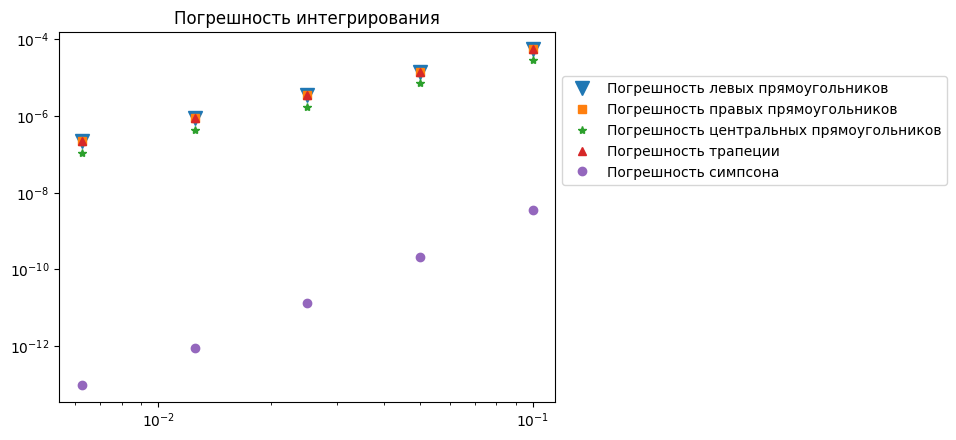

Значения тангенсов углов наклона прямых:
 левые 2.00
 правые 2.00
 центральные 2.00
 трапеции 2.00
 симпсон 3.82


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def f(x):
    '''True function'''
    return 1/(1 + np.cos(x/5))

def y(a, b):
    '''Exact value of the Integral'''
    return 5*np.tan(b/10) - 5*np.tan(a/10)

# функции для вычисления интеграла
def y_lr(x, h):
    '''Integral using left rectangles'''
    return np.sum(h * f(x[:-1]))

def y_rr(x, h):
    '''Integral using right rectangles'''
    return np.sum(h * f(x[1:]))

def y_cr(x, h):
    '''Integral using central rectangles'''
    return np.sum(h * f(x[:-1] + h/2))

def y_t(x, h):
    '''Integral using Trapezoid formula'''
    return np.sum(h * (f(x[:-1]) + f(x[:-1] + h))/2)

def y_s(x, h): # требуется нечетное количество точек
    '''Integral using Simpson`s formula'''
    return h / 3 * (f(a) + 4 * np.sum(f(x[1:-1:2])) + 2 * np.sum(f(x[2:-1:2])) + f(b))


# входные данные
a = -3 #float(input())
b = 3 #float(input())
h_array = np.array([0.1, 0.05, 0.025, 0.0125, 0.00625])

# функции для вычисления ошибок интегрирования
def ey_lr(x, i):
    return np.abs(y(a, b) - y_lr(x, i))

def ey_rr(x, i):
    return np.abs(y(a, b) - y_rr(x, i))

def ey_cr(x, i):
    return np.abs(y(a, b) - y_cr(x, i))

def ey_t(x, i):
    return np.abs(y(a, b) - y_t(x, i))

def ey_s(x, i):
    return np.abs(y(a, b) - y_s(x, i))

# ошибки интегрирования
ey_left = []
ey_center = []
ey_right = []
ey_trapezoid = []
ey_simpson = []

# Перебираем все значения шагов для узлов
for i in h_array:

    n_points = int((b - a)/i) + 1 # чтобы погрешность от шага не набегала
    x = np.linspace(a, b, n_points) # точный контроль точек
    h_actual = x[1] - x[0]

    # для cимпсона проверяем четное количество интервалов
    if len(x) % 2 == 0:
        # если количество точек четное, добавляем еще одну точку
        x = np.linspace(a, b, n_points )
        h_actual = x[1] - x[0]

    ey_left.append(ey_lr(x, h_actual))
    ey_right.append(ey_rr(x, h_actual))
    ey_center.append(ey_cr(x, h_actual))
    ey_trapezoid.append(ey_t(x, h_actual))
    ey_simpson.append(ey_s(x, h_actual))

print('Значения погрешностей для каждого из методов при разных шагах:\n')
data = {
    'Шаг': h_array,
    'ey_left': ey_left,
    'ey_center': ey_center,
    'ey_right': ey_right,
    'ey_trapezoid': ey_trapezoid,
    'ey_simpson': ey_simpson
}
df = pd.DataFrame(data)
print(df)

plt.title("Погрешность интегрирования")
plt.plot(h_array, ey_left, label = "Погрешность левых прямоугольников", linestyle = " ", marker = "v", markersize = 10)
plt.plot(h_array, ey_right, label = "Погрешность правых прямоугольников", linestyle = " ", marker = "s")
plt.plot(h_array, ey_center, label = "Погрешность центральных прямоугольников", linestyle = " ", marker = "*")
plt.plot(h_array, ey_trapezoid, label = "Погрешность трапеции", linestyle = " ", marker = "^")
plt.plot(h_array, ey_simpson, label = "Погрешность симпсона", linestyle = " ", marker = "o")

plt.xscale("log")
plt.yscale("log")
plt.legend(bbox_to_anchor=(1, 0.9)) #
plt.show()

print('Значения тангенсов углов наклона прямых:')
print(f' левые {np.polyfit(np.log(h_array), np.log(ey_left), 1)[0]:.2f}')
print(f' правые {np.polyfit(np.log(h_array), np.log(ey_right), 1)[0]:.2f}')
print(f' центральные {np.polyfit(np.log(h_array), np.log(ey_center), 1)[0]:.2f}')
print(f' трапеции {np.polyfit(np.log(h_array), np.log(ey_trapezoid), 1)[0]:.2f}')
print(f' симпсон {np.polyfit(np.log(h_array), np.log(ey_simpson), 1)[0]:.2f}')
